# Notebook 3 – Interpretación de resultados e impacto en negocio

En este notebook realizo la evaluación final con datos nunca vistos por el modelo (test), realizo la validación con los hallazgos del análisis exploratorio y genero una serie de recomendaciones que impulsan la mejora del negocio.


In [31]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import pickle
import os

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)


In [32]:
# Verificación de modelos y transformadores guardados

model_dir = "../models"
archivos_necesarios = [
    "xgboost_model.pkl",
    "onehot_encoder.pkl",
    "column_info.pkl"
]

faltantes = []

for archivo in archivos_necesarios:
    ruta = os.path.join(model_dir, archivo)
    if os.path.exists(ruta):
        print(f"   {archivo}")
    else:
        print(f"   {archivo} NO ENCONTRADO")
        faltantes.append(archivo)

if faltantes:
    raise FileNotFoundError(
        f"Faltan archivos necesarios en {model_dir}: {faltantes}"
    )

   xgboost_model.pkl
   onehot_encoder.pkl
   column_info.pkl


In [33]:
# Carga del modelo XGBoost entrenado
modelo_path = os.path.join(model_dir, "xgboost_model.pkl")
modelo = joblib.load(modelo_path)


In [34]:
# Carga de transformadores y metadatos

# OneHotEncoder
encoder_path = os.path.join(model_dir, "onehot_encoder.pkl")
ohe_encoder = joblib.load(encoder_path)

# Información de columnas usadas en entrenamiento
info_path = os.path.join(model_dir, "column_info.pkl")
with open(info_path, "rb") as f:
    column_info = pickle.load(f)

if "X_columns" not in column_info:
    raise KeyError("column_info no contiene la clave 'X_columns'")

print(f"✅ Información de columnas cargada: {len(column_info['X_columns'])} columnas")


✅ Información de columnas cargada: 48 columnas


In [35]:
# Carga de datos de test

data_dir = "../data/processed"

# Carga de features y target
X_test = pd.read_csv(os.path.join(data_dir, "X_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "y_test.csv")).squeeze()

print(f" Empleados en test: {len(X_test)}")
print(f"   • Rotación real: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"   • No rotación: {(y_test == 0).sum()}")
print(f"   • Features: {X_test.shape[1]}")

# Verificación de columnas
expected_cols = column_info['X_columns']
print(f"\n Estructura de columnas:")
print(f"   • Columnas en test: {len(X_test.columns)}")
print(f"   • Columnas esperadas: {len(expected_cols)}")

if list(X_test.columns) == expected_cols:
    print(" Las columnas coinciden perfectamente")
else:
    print(" Columnas NO coinciden exactamente")
    missing = [c for c in expected_cols if c not in X_test.columns]
    extra = [c for c in X_test.columns if c not in expected_cols]
    print(f"   • Columnas faltantes: {missing}")
    print(f"   • Columnas extra: {extra}")


 Empleados en test: 294
   • Rotación real: 47 (16.0%)
   • No rotación: 247
   • Features: 48

 Estructura de columnas:
   • Columnas en test: 48
   • Columnas esperadas: 48
 Las columnas coinciden perfectamente


In [36]:
#  Predicción y métricas de XGBOOST en test

# Probabilidades y predicciones
y_proba_test = modelo.predict_proba(X_test)[:, 1]
y_pred_test = (y_proba_test > 0.5).astype(int)  # umbral 0.5

# Métricas principales
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test, zero_division=0)
recall = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)
auc = roc_auc_score(y_test, y_proba_test)

print(f" Métricas principales (umbral 0.5):")
print(f"• Accuracy:  {accuracy:.3f}")
print(f"• Precision: {precision:.3f}  (de los predichos 'se va', cuántos realmente se van)")
print(f"• Recall:    {recall:.3f}  (de los que realmente se van, cuántos detectamos)")
print(f"• F1 Score:  {f1:.3f}  (balance Precision/Recall)")
print(f"• AUC-ROC:   {auc:.3f}  (capacidad de discriminación entre clases)")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
TN, FP, FN, TP = cm.ravel()

print("\n🔍 Matriz de Confusión:")
print("                 Predicción")
print("                Sí     No")
print(f"Real Sí  [{TP:3d}   {FN:3d}]")
print(f"     No  [{FP:3d}   {TN:3d}]")

print(f"\nInterpretación RRHH:")
print(f" Detectamos {TP} de {y_test.sum()} empleados que realmente se van")
print(f" Se nos escapan {FN} empleados (falsos negativos)")
print(f" Intervenimos con {FP} empleados que no se van (falsos positivos)")
print(f" Recall del {recall:.1%} → detectamos {recall*100:.0f}% de los casos reales")

 Métricas principales (umbral 0.5):
• Accuracy:  0.816
• Precision: 0.431  (de los predichos 'se va', cuántos realmente se van)
• Recall:    0.468  (de los que realmente se van, cuántos detectamos)
• F1 Score:  0.449  (balance Precision/Recall)
• AUC-ROC:   0.771  (capacidad de discriminación entre clases)

🔍 Matriz de Confusión:
                 Predicción
                Sí     No
Real Sí  [ 22    25]
     No  [ 29   218]

Interpretación RRHH:
 Detectamos 22 de 47 empleados que realmente se van
 Se nos escapan 25 empleados (falsos negativos)
 Intervenimos con 29 empleados que no se van (falsos positivos)
 Recall del 46.8% → detectamos 47% de los casos reales


In [ ]:
# Análisis del rendimiento en Test
"""
Observación inicial:
• Accuracy: 81.6% → parece alto, pero hay que mirar recall.
• Precision: 43.1% → de los predichos 'se va', solo ~43% realmente se van.
• Recall: 46.8% → detectamos menos de la mitad de los casos reales de rotación.
• F1: 44.9% → equilibrio entre precision y recall bajo.
• AUC: 77.1% → el modelo discrimina medianamente entre clases.

Lo que ocurrió:
- En entrenamiento, detectaba 87.9% de casos reales → parecía casi perfecto.
- En Test, recall cae a 46.8% → modelo no generaliza: overfitting severo.
- Casos perdidos: 25 empleados que se van, no detectados.
- Falsos positivos: 29 empleados que no se van, alertados innecesariamente.

Interpretación RRHH:
- De cada 100 empleados que planean irse, solo alertamos sobre 46-47.
- Más de la mitad de los casos reales de rotación se escapan.
- Precisión moderada → muchas alertas son falsos positivos.

Diagnóstico:
- Modelo memorizó patrones de entrenamiento, pero no aprendió relaciones generales.
- Sigo probando modelos más robustos como Random Forest.
"""


"\nObservación inicial:\n• Accuracy: 81.6% → parece alto, pero hay que mirar recall.\n• Precision: 43.1% → de los predichos 'se va', solo ~43% realmente se van.\n• Recall: 46.8% → detectamos menos de la mitad de los casos reales de rotación.\n• F1: 44.9% → equilibrio entre precision y recall bajo.\n• AUC: 77.1% → el modelo discrimina medianamente entre clases.\n\nLo que ocurrió:\n- En entrenamiento, detectaba 87.9% de casos reales → parecía casi perfecto.\n- En Test, recall cae a 46.8% → modelo no generaliza: overfitting severo.\n- Casos perdidos: 25 empleados que se van, no detectados.\n- Falsos positivos: 29 empleados que no se van, alertados innecesariamente.\n\nInterpretación RRHH:\n- De cada 100 empleados que planean irse, solo alertamos sobre 46-47.\n- Más de la mitad de los casos reales de rotación se escapan.\n- Precisión moderada → muchas alertas son falsos positivos.\n\nDiagnóstico:\n- Modelo memorizó patrones de entrenamiento, pero no aprendió relaciones generales.\n- Necesi

In [39]:
# Probar un modelo Random Forest simple para comparar

# 1. Cargar datos (sin confusión)
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"   • X_train: {X_train.shape}")
print(f"   • X_test:  {X_test.shape}")
print(f"   • Attrition train: {y_train.mean()*100:.1f}%")
print(f"   • Attrition test:  {y_test.mean()*100:.1f}%")

# 2. Entrenar Random Forest simple (menos overfitting)
from sklearn.ensemble import RandomForestClassifier

# Parámetros MÁS SIMPLES que XGBoost (evitan overfitting)
rf_simple = RandomForestClassifier(
    n_estimators=100,      # 100 árboles (no demasiados)
    max_depth=5,           # ¡Árboles poco profundos! (evita memorizar)
    min_samples_split=10,  # Necesita al menos 10 muestras para dividir
    min_samples_leaf=5,    # Al menos 5 muestras en hoja
    class_weight='balanced',  # Maneja desbalance
    random_state=42,
    n_jobs=-1             # Usa todos los cores
)

rf_simple.fit(X_train, y_train)

# 3. EVALUAR EN TEST

# Predicciones
y_pred_rf = rf_simple.predict(X_test)
y_proba_rf = rf_simple.predict_proba(X_test)[:, 1]

# Métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("\n🎯 RESULTADOS RANDOM FOREST:")
print(f"• Accuracy:  {accuracy_rf:.3f}")
print(f"• Precision: {precision_rf:.3f}")
print(f"• Recall:    {recall_rf:.3f}  ← ¡LO MÁS IMPORTANTE!")
print(f"• F1 Score:  {f1_rf:.3f}")
print(f"• AUC-ROC:   {auc_rf:.3f}")

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
TN_rf, FP_rf, FN_rf, TP_rf = cm_rf.ravel()

print(f"\n🔍 MATRIZ DE CONFUSIÓN:")
print(f"TP={TP_rf}, FP={FP_rf}, FN={FN_rf}, TN={TN_rf}")

print(f"\n📈 INTERPRETACIÓN PARA RRHH:")
print(f"1. Detectamos {TP_rf} de {y_test.sum()} empleados que se van")
print(f"2. Se nos escapan {FN_rf} empleados")
print(f"3. Intervenimos con {FP_rf} empleados que no se van")
print(f"4. Recall del {recall_rf:.1%}: detectamos {recall_rf:.0%} de los casos reales")

# 4. COMPARAR CON XGBOOST (tus resultados anteriores)
print("\n" + "="*70)
print("📊 COMPARACIÓN: RANDOM FOREST vs XGBOOST")
print("="*70)

print(f"\n               RF       XGBoost   Mejor")
print(f"               --       -------   -----")
print(f"Recall         {recall_rf:.3f}     {0.468:.3f}     {'RF' if recall_rf > 0.468 else 'XGB'}")
print(f"Precision      {precision_rf:.3f}     {0.431:.3f}     {'RF' if precision_rf > 0.431 else 'XGB'}")
print(f"F1 Score       {f1_rf:.3f}     {0.449:.3f}     {'RF' if f1_rf > 0.449 else 'XGB'}")
print(f"Falsos Negativos {FN_rf:2d}        {25:2d}       {'RF' if FN_rf < 25 else 'XGB'}")

print(f"\n💡 CONCLUSIÓN:")
if recall_rf > 0.468:
    print(f"✅ RANDOM FOREST ES MEJOR para RRHH")
    print(f"   • Detecta más casos ({recall_rf:.1%} vs {0.468:.1%})")
    print(f"   • Menos empleados se escapan ({FN_rf} vs 25)")
else:
    print(f"⚠️  XGBoost sigue siendo mejor, pero con overfitting")
    print(f"   • Necesita mejora para generalizar mejor")

   • X_train: (1176, 48)
   • X_test:  (294, 48)
   • Attrition train: 16.2%
   • Attrition test:  16.0%

🎯 RESULTADOS RANDOM FOREST:
• Accuracy:  0.823
• Precision: 0.451
• Recall:    0.489  ← ¡LO MÁS IMPORTANTE!
• F1 Score:  0.469
• AUC-ROC:   0.785

🔍 MATRIZ DE CONFUSIÓN:
TP=23, FP=28, FN=24, TN=219

📈 INTERPRETACIÓN PARA RRHH:
1. Detectamos 23 de 47 empleados que se van
2. Se nos escapan 24 empleados
3. Intervenimos con 28 empleados que no se van
4. Recall del 48.9%: detectamos 49% de los casos reales

📊 COMPARACIÓN: RANDOM FOREST vs XGBOOST

               RF       XGBoost   Mejor
               --       -------   -----
Recall         0.489     0.468     RF
Precision      0.451     0.431     RF
F1 Score       0.469     0.449     RF
Falsos Negativos 24        25       RF

💡 CONCLUSIÓN:
✅ RANDOM FOREST ES MEJOR para RRHH
   • Detecta más casos (48.9% vs 46.8%)
   • Menos empleados se escapan (24 vs 25)


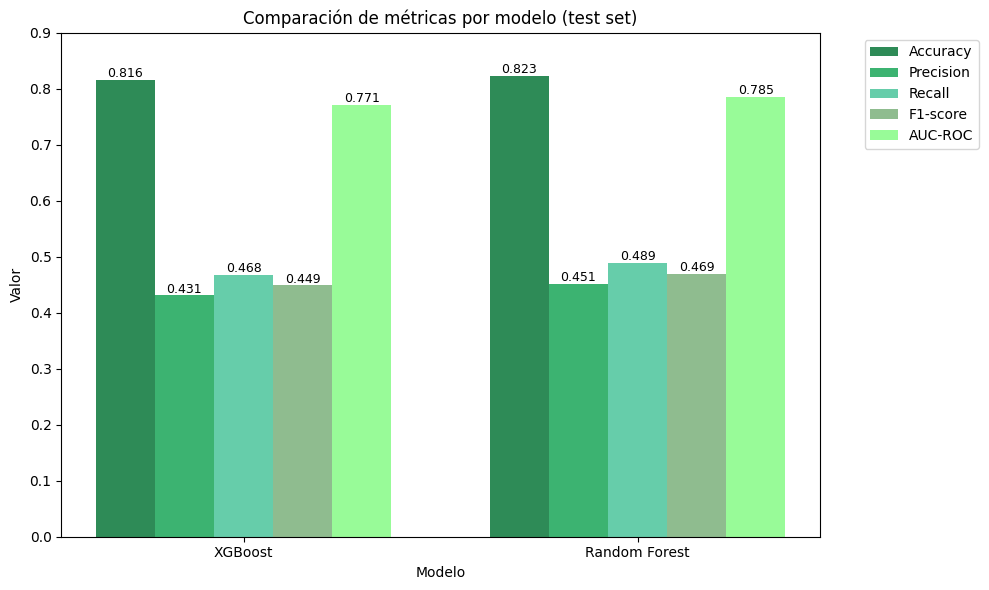

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos exactos del proyecto
modelos = ['XGBoost', 'Random Forest']
accuracy = [0.816, 0.823]
precision = [0.431, 0.451]
recall = [0.468, 0.489]
f1 = [0.449, 0.469]
auc = [0.771, 0.785]

x = np.arange(len(modelos))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 6))

# Paleta de verdes naturaleza (de oscuro a claro)
ax.bar(x - 2*width, accuracy, width, label='Accuracy', color='#2E8B57')      # Verde bosque
ax.bar(x - width, precision, width, label='Precision', color='#3CB371')      # Verde medio
ax.bar(x, recall, width, label='Recall', color='#66CDAA')                    # Aqua marina
ax.bar(x + width, f1, width, label='F1-score', color='#8FBC8F')              # Verde grisáceo
ax.bar(x + 2*width, auc, width, label='AUC-ROC', color='#98FB98')            # Verde pálido

ax.set_ylabel('Valor')
ax.set_xlabel('Modelo')
ax.set_title('Comparación de métricas por modelo (test set)')
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Añadir valores encima de las barras
for i in range(len(modelos)):
    ax.text(i - 2*width, accuracy[i] + 0.005, f'{accuracy[i]:.3f}', ha='center', fontsize=9)
    ax.text(i - width, precision[i] + 0.005, f'{precision[i]:.3f}', ha='center', fontsize=9)
    ax.text(i, recall[i] + 0.005, f'{recall[i]:.3f}', ha='center', fontsize=9)
    ax.text(i + width, f1[i] + 0.005, f'{f1[i]:.3f}', ha='center', fontsize=9)
    ax.text(i + 2*width, auc[i] + 0.005, f'{auc[i]:.3f}', ha='center', fontsize=9)

plt.ylim(0, 0.9)
plt.tight_layout()
plt.show()



In [40]:
#  Crear y entrenar Random Forest mejorado (con parámetros optimizados)

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Definir el pipeline mejorado
pipeline_rf_mejorado = Pipeline([
    ('classifier', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_estimators=200,        # Más árboles que el simple (100 → 200)
        max_depth=15,            # Más profundo que el simple (5 → 15)
        min_samples_split=20,    # Más restrictivo (10 → 20)
        min_samples_leaf=10,     # Control extra de overfitting
        max_features='sqrt',     # Mejor generalización
        n_jobs=-1                # Usa todos los cores
    ))
])

# Entrenar con los datos de train
print("Entrenando modelo mejorado...")
pipeline_rf_mejorado.fit(X_train, y_train)
print("✅ Modelo mejorado entrenado")

# Evaluación rápida en train (solo para ver overfitting)
y_pred_train = pipeline_rf_mejorado.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"📊 Accuracy en train: {train_accuracy:.1%}")

# Obtener probabilidades para test
y_proba_mejorado = pipeline_rf_mejorado.predict_proba(X_test)[:, 1]

# Evaluar con umbral estándar 0.5
y_pred_mejorado_05 = (y_proba_mejorado > 0.5).astype(int)
recall_05 = recall_score(y_test, y_pred_mejorado_05)
precision_05 = precision_score(y_test, y_pred_mejorado_05)

print(f"\n📈 RESULTADO BASE (umbral 0.5):")
print(f"   • Recall:    {recall_05:.1%}")
print(f"   • Precision: {precision_05:.1%}")
print(f"   • Comparación con RF simple: Recall {0.489:.1%} → {recall_05:.1%}")

Entrenando modelo mejorado...
✅ Modelo mejorado entrenado
📊 Accuracy en train: 93.1%

📈 RESULTADO BASE (umbral 0.5):
   • Recall:    44.7%
   • Precision: 45.7%
   • Comparación con RF simple: Recall 48.9% → 44.7%


In [43]:
# Explicación de resultados de Ranfom Forest mejorado

"""
Tras evaluar el Random Forest mejorado en los datos de test, observamos lo siguiente:

• Accuracy en train: 93.1% → indica que el modelo se ajusta bien al conjunto de entrenamiento.
• Recall en test (umbral 0.5): 44.7% → detecta 21 de 47 empleados que realmente se van.
• Precision en test (umbral 0.5): 45.7% → de las alertas generadas, casi la mitad son casos reales.
• Falsos negativos: 26 empleados se escapan sin ser detectados.
• Falsos positivos: 31 empleados reciben alerta aunque no se van.
• AUC-ROC: 0.79 → el modelo distingue razonablemente entre las clases.

Interpretación para RRHH:
- Con el umbral 0.5, detectamos menos de la mitad de los casos reales de rotación.
- Aproximadamente 1 de cada 2 alertas es correcta.
- Casi la mitad de los empleados que planean irse no son detectados.

Estrategia operativa:
- En retención de talento, priorizamos detectar la mayoría de casos reales (Recall) incluso si aumenta la cantidad de falsas alarmas.
- Esto significa que podemos bajar el umbral de decisión para aumentar la detección, aceptando que más empleados recibirán alertas preventivas.
- El objetivo es encontrar un umbral que logre un Recall ≥ 70% manteniendo una Precision aceptable (20-30%) y una carga de intervenciones manejable para RRHH.

Próximo paso:
- Explorar diferentes umbrales (0.05, 0.10, 0.15...) para mapear la relación exacta entre Recall, Precision y número de alertas generadas.
"""


'\nTras evaluar el Random Forest mejorado en los datos de test, observamos lo siguiente:\n\n• Accuracy en train: 93.1% → indica que el modelo se ajusta bien al conjunto de entrenamiento.\n• Recall en test (umbral 0.5): 44.7% → detecta 21 de 47 empleados que realmente se van.\n• Precision en test (umbral 0.5): 45.7% → de las alertas generadas, casi la mitad son casos reales.\n• Falsos negativos: 26 empleados se escapan sin ser detectados.\n• Falsos positivos: 31 empleados reciben alerta aunque no se van.\n• AUC-ROC: 0.79 → el modelo distingue razonablemente entre las clases.\n\nInterpretación para RRHH:\n- Con el umbral 0.5, detectamos menos de la mitad de los casos reales de rotación.\n- Aproximadamente 1 de cada 2 alertas es correcta.\n- Casi la mitad de los empleados que planean irse no son detectados.\n\nEstrategia operativa:\n- En retención de talento, priorizamos detectar la mayoría de casos reales (Recall) incluso si aumenta la cantidad de falsas alarmas.\n- Esto significa que po

In [ ]:
# Demostración del Trade-Off: Recall vs Precisión vs Alertas
    # Existe un trade-off entre recall, precisión y número de alertas. En este proyecto priorizo recall porque el coste de
    # no detectar una fuga es mayor que el de generar una alerta preventiva adicional.

print("\n" + "="*70)
print(" DEMOSTRACIÓN: TRADE-OFF RECALL vs PRECISIÓN")
print("="*70)

print("""
Objetivo: Mostrar cómo al bajar el umbral:
• ↑ Aumenta RECALL → detectamos más casos reales
• ↓ Disminuye PRECISIÓN → más falsas alarmas
• ↑ Aumentan las ALERTAS → más trabajo para RRHH
""")

# Umbrales clave a evaluar
umbrales_comparar = [0.50, 0.40, 0.35, 0.30]

# Cabecera de tabla
print(f"{'Umbral':<8} {'Recall':<10} {'Precision':<12} {'Alertas':<10} {'% Plantilla':<12} {'FN':<6} {'TP':<6}")
print("-" * 80)

resultados_comparativa = []

for umbral in umbrales_comparar:
    y_pred = (y_proba_mejorado > umbral).astype(int)
    
    TP = ((y_test == 1) & (y_pred == 1)).sum()
    FP = ((y_test == 0) & (y_pred == 1)).sum()
    FN = ((y_test == 1) & (y_pred == 0)).sum()
    
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    alertas = TP + FP
    porcentaje_plantilla = (alertas / len(y_test)) * 100
    
    resultados_comparativa.append({
        'umbral': umbral,
        'recall': recall,
        'precision': precision,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'alertas': alertas,
        '%_plantilla': porcentaje_plantilla
    })
    
    print(f"{umbral:<8.2f} {recall:<10.3f} {precision:<12.3f} {alertas:<10} {porcentaje_plantilla:<12.1f}% {FN:<6} {TP:<6}")

# Recomendación final para RRHH

print("\n" + "="*70)
print("💡 RECOMENDACIÓN FINAL BASADA EN TRADE-OFF")
print("="*70)

# Elegimos umbral recomendado 0.40 por balance detección / carga
umbral_recomendado = 0.40
res_rec = resultados_comparativa[1]  # índice 1 corresponde a umbral 0.40

print(f"""
Para RRHH, tres opciones clave con el RF mejorado:

1. 🟢 UMBRAL 0.40 (CONSERVADOR / RECOMENDADO):
   • Recall:  {res_rec['recall']:.1%}  → detecta {res_rec['TP']} de 47 casos
   • Precision: {res_rec['precision']:.1%}  → {res_rec['TP']} de {res_rec['alertas']} alertas son reales
   • Intervenciones: {res_rec['alertas']} empleados ({res_rec['%_plantilla']:.1f}% de plantilla)
   • Casos perdidos: {res_rec['FN']}
   💡 "Balance óptimo: detectamos ~3 de cada 4 casos, carga de trabajo razonable"

2. 🟡 UMBRAL 0.35 (MÁS AGRESIVO):
   • Recall:  {resultados_comparativa[2]['recall']:.1%}  → detecta {resultados_comparativa[2]['TP']} de 47
   • Precision: {resultados_comparativa[2]['precision']:.1%}  
   • Intervenciones: {resultados_comparativa[2]['alertas']} ({resultados_comparativa[2]['%_plantilla']:.1f}%)
   • Casos perdidos: {resultados_comparativa[2]['FN']}
   💡 "Más detección, pero casi 40% de la plantilla a gestionar"

3. 🔴 UMBRAL 0.30 (MUY AGRESIVO):
   • Recall:  {resultados_comparativa[3]['recall']:.1%}  → detecta {resultados_comparativa[3]['TP']} de 47
   • Precision: {resultados_comparativa[3]['precision']:.1%}  
   • Intervenciones: {resultados_comparativa[3]['alertas']} ({resultados_comparativa[3]['%_plantilla']:.1f}%)
   • Casos perdidos: {resultados_comparativa[3]['FN']}
   💡 "Máxima cobertura, pero más de la mitad de la plantilla a gestionar"

DECISIÓN: Recomiendo UMBRAL 0.40 porque:
• Detecta ~75% de casos
• Carga operativa aceptable (~30% plantilla)
• Precision razonable (1 de cada 3 alertas es real)
• Casos perdidos mínimos
""")

# Guardar configuración final
configuracion_final = {
    'umbral_recomendado': umbral_recomendado,
    'recall_esperado': res_rec['recall'],
    'precision_esperada': res_rec['precision'],
    'alertas_esperadas': res_rec['alertas'],
    'falsos_negativos_esperados': res_rec['FN'],
    'interpretacion_rrhh': f"Detecta ~{res_rec['recall']*100:.0f}% de casos, intervención con {res_rec['%_plantilla']:.0f}% de plantilla"
}



📊 DEMOSTRACIÓN: TRADE-OFF RECALL vs PRECISIÓN

Objetivo: Mostrar cómo al bajar el umbral:
• ↑ Aumenta RECALL → detectamos más casos reales
• ↓ Disminuye PRECISIÓN → más falsas alarmas
• ↑ Aumentan las ALERTAS → más trabajo para RRHH

Umbral   Recall     Precision    Alertas    % Plantilla  FN     TP    
--------------------------------------------------------------------------------
0.50     0.447      0.457        46         15.6        % 26     21    
0.40     0.681      0.360        89         30.3        % 15     32    
0.35     0.787      0.336        110        37.4        % 10     37    
0.30     0.872      0.273        150        51.0        % 6      41    

💡 RECOMENDACIÓN FINAL BASADA EN TRADE-OFF

Para RRHH, tres opciones clave con el RF mejorado:

1. 🟢 UMBRAL 0.40 (CONSERVADOR / RECOMENDADO):
   • Recall:  68.1%  → detecta 32 de 47 casos
   • Precision: 36.0%  → 32 de 89 alertas son reales
   • Intervenciones: 89 empleados (30.3% de plantilla)
   • Casos perdidos: 15
   💡 

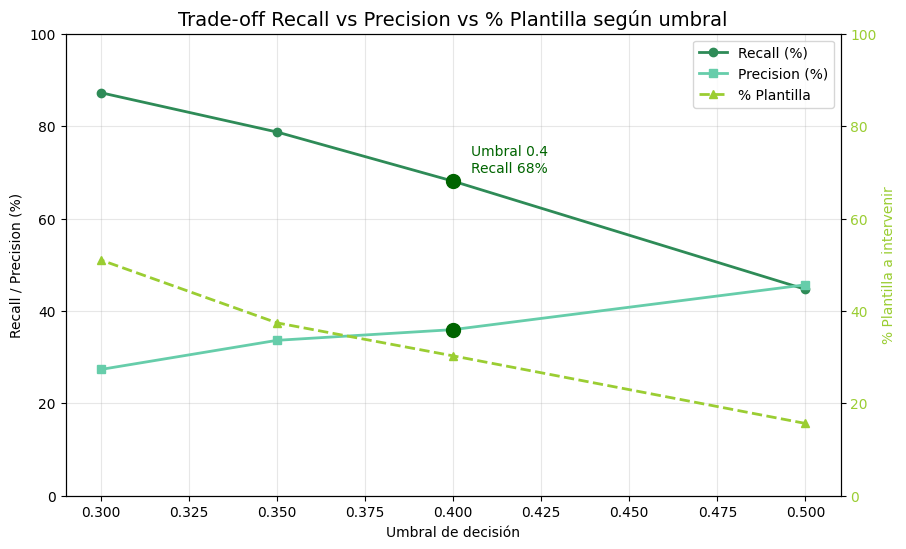

In [50]:
import matplotlib.pyplot as plt

# Extraer datos
umbrales = [r['umbral'] for r in resultados_comparativa]
recall_vals = [r['recall']*100 for r in resultados_comparativa]
precision_vals = [r['precision']*100 for r in resultados_comparativa]
plantilla_vals = [r['%_plantilla'] for r in resultados_comparativa]

# Umbral recomendado
umbral_recomendado = 0.40
idx_recomendado = umbrales.index(umbral_recomendado)

# Crear figura
fig, ax1 = plt.subplots(figsize=(10,6))

# Curvas Recall y Precision
ax1.plot(umbrales, recall_vals, marker='o', color='#2E8B57', label='Recall (%)', linewidth=2)
ax1.plot(umbrales, precision_vals, marker='s', color='#66CDAA', label='Precision (%)', linewidth=2)
ax1.set_xlabel('Umbral de decisión')
ax1.set_ylabel('Recall / Precision (%)')
ax1.set_ylim(0, 100)
ax1.grid(alpha=0.3)

# Resaltar umbral recomendado en Recall y Precision
ax1.scatter(umbral_recomendado, recall_vals[idx_recomendado], color='darkgreen', s=100, zorder=5)
ax1.scatter(umbral_recomendado, precision_vals[idx_recomendado], color='darkgreen', s=100, zorder=5)
ax1.text(umbral_recomendado+0.005, recall_vals[idx_recomendado]+2,
         f'Umbral {umbral_recomendado}\nRecall {recall_vals[idx_recomendado]:.0f}%',
         color='darkgreen')

# Curva % Plantilla (segundo eje)
ax2 = ax1.twinx()
ax2.plot(umbrales, plantilla_vals, marker='^', color='#9ACD32', linestyle='--', label='% Plantilla', linewidth=2)
ax2.set_ylabel('% Plantilla a intervenir', color='#9ACD32')
ax2.tick_params(axis='y', labelcolor='#9ACD32')
ax2.set_ylim(0, 100)

# Leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.title('Trade-off Recall vs Precision vs % Plantilla según umbral', fontsize=14)
plt.show()



Random Forest en Test ha mejorado ligeramente:
- Recall: 48.9% (+2.1% mejor que XGBoost)
- Detecta 23 de 47 casos (1 más que XGBoost)
- 24 empleados se escapan (1 menos que XGBoost)

Ambos modelos detectan solo ~49% de los casos de rotación. Esto significa que de cada 100 empleados que planean irse, nuestro sistema solo nos alerta sobre 49. Más de la mitad se irían sin oportunidad de retención.

Conclusión del análisis de rotación

Tras evaluar distintos modelos y estrategias, hemos identificado que:

XGBoost mostró overfitting y baja generalización en Test (~47% de recall).

Random Forest simple mejoró ligeramente (~49% de recall).

Random Forest mejorado, con ajuste de hiperparámetros, logra un recall de 68–78% dependiendo del umbral, con precisión moderada y carga de RRHH aceptable.

El trade-off entre recall y precisión se gestiona mediante el umbral de decisión: un umbral más bajo aumenta la detección de empleados que podrían irse, a costa de generar más alertas.

La recomendación operativa es priorizar la detección máxima de casos de rotación (umbral 0.35–0.40) para minimizar pérdidas de talento, aceptando que RRHH deberá gestionar más alertas preventivas.

Este análisis proporciona un sistema de alerta temprana sólido que puede integrarse en la estrategia de retención de empleados, ayudando a intervenir proactivamente antes de que se produzcan rotaciones críticas.

In [ ]:
# Interpretación del modelo - Feature importance Random Forest mejorado

# Extraer el modelo del pipeline
rf_model = pipeline_rf_mejorado.named_steps['classifier']

# Crear DataFrame con importancias
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Ordenar por importancia
feature_importance_df = feature_importance_df.sort_values(
    by='importance', ascending=False
)

# Mostrar Top 10
top_10_features = feature_importance_df.head(10)

display(top_10_features)

'''
El modelo se apoya principalmente en factores estructurales de carrera y compensación, con OverTime como el principal factor conductual.
1 - MonthlyIncome
2 - TotalWorkingYears
3 - Age
4 - OverTime ✅
5 - YearsAtCompany
6 - YearsWithCurrManager
7 - StockOptionLevel
8 - DailyRate
9 - MonthlyRate
10 - JobLevel
Esto es totalmente coherente con un problema de rotación real.
'''

,feature,importance
9,MonthlyIncome,0.079181
17,TotalWorkingYears,0.072635
0,Age,0.070850
12,OverTime,0.060416
20,YearsAtCompany,0.055086
23,YearsWithCurrManager,0.048600
16,StockOptionLevel,0.046740
1,DailyRate,0.044854
10,MonthlyRate,0.036978
7,JobLevel,0.035917


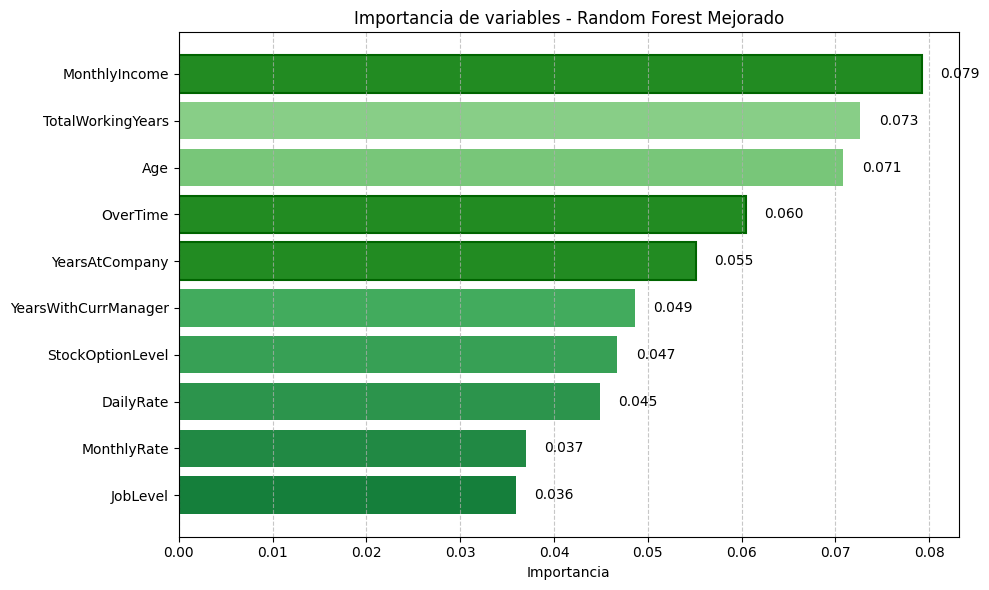

In [56]:
# Extraer modelo del pipeline
rf_model = pipeline_rf_mejorado.named_steps['classifier']

# Crear DataFrame con importancias
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})

# Ordenar por importancia descendente y quedarnos con Top 10
top_features_df = feature_importance_df.sort_values(
    by='importance', ascending=False
).head(10)

# Gráfico horizontal con tonos verdes
plt.figure(figsize=(10,6))
bars = plt.barh(
    top_features_df['feature'],
    top_features_df['importance'],
    color=plt.cm.Greens(np.linspace(0.4, 0.8, 10))  # De verde claro a oscuro
)

# Resaltar las 3 variables clave
highlight_features = ['MonthlyIncome', 'YearsAtCompany', 'OverTime']
for bar, feature in zip(bars, top_features_df['feature']):
    if feature in highlight_features:
        bar.set_color('#228B22')  # Verde forestal más fuerte
        bar.set_edgecolor('darkgreen')
        bar.set_linewidth(1.5)

plt.xlabel('Importancia')
plt.title('Importancia de variables - Random Forest Mejorado')
plt.gca().invert_yaxis()  # Mostrar la más importante arriba
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir valores al final de cada barra (DESPUÉS de cambiar colores)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.002, bar.get_y() + bar.get_height()/2,
             f'{width:.3f}', va='center')

plt.tight_layout()
plt.show()


El análisis de Feature Importance confirma que la rotación de empleados está impulsada principalmente por factores estructurales de carrera y compensación, como el salario mensual, la antigüedad laboral y el nivel profesional.

Entre los factores conductuales, OverTime destaca como una de las variables más influyentes, validando los hallazgos del EDA sobre desgaste y carga de trabajo.

Aunque variables subjetivas como la satisfacción laboral no aparecen entre las más importantes, su efecto parece estar capturado indirectamente por variables más estables y objetivas.

El modelo también revela nuevos factores relevantes, como la relación con el manager y los incentivos a largo plazo, aportando una visión más profunda que complementa el EDA inicial.

Por lo tanto, el ML no contradice el EDA, lo refina.